# Task 1.5: Analysis of Resource Availabilities of the BPIC-17 Eventlog

### Imports and Setup

In [1]:
import pm4py as pm
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
log = pm.read_xes("../../data/BPI Challenge 2017.xes.gz")
df_raw = pm.convert_to_dataframe(log)

/Users/matildabriegel/opt/anaconda3/envs/bppso/lib/python3.12/site-packages/pm4py/utils.py:992: UserWarning: Install the optional requirement `rustxes` to import/export files faster.
  warnings.warn("Install the optional requirement `rustxes` to import/export files faster.")


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [3]:
df_whole = df_raw.copy()

Data Cleaning

In [4]:
df_whole.rename(columns={
    'org:resource': 'Resource',
    'concept:name': 'Activity',
    'time:timestamp': 'Timestamp',
    'lifecycle:transition': 'State',
    'case:concept:name': 'Case'
}, inplace=True)
df_whole.drop(columns=['EventOrigin', 'EventID', 'case:LoanGoal', 'case:ApplicationType', 'case:RequestedAmount',
       'FirstWithdrawalAmount', 'NumberOfTerms', 'Accepted', 'MonthlyCost',
       'Selected', 'CreditScore', 'OfferedAmount', 'OfferID'], inplace=True)

df_whole['ResourceId'] = df_whole['Resource'].astype(str).str.lstrip('User_').astype(int)   # Used for sorting and quicker access
df_whole['Date'] = df_whole['Timestamp'].dt.date    # Needed for grouping
df_whole['Time'] = df_whole['Timestamp'].dt.time

In [5]:
# Use filtered dataframe from bpnm model for analysis
df_filtered = df_whole[~df_whole['Activity'].isin(['W_Assess potential fraud', 'W_Shortened completion ', 'W_Personal Loan collection', 'O_Sent (online only)'])]     # Activities not in bpmn model
df_filtered = df_filtered[df_filtered['State'].isin(['start', 'complete'])]

In [29]:
# Set df value for analysis
df = df_filtered
df = df.sort_values(['Resource', 'Timestamp'])

## Basic Approach
Daily Schedules based on median for 1-week interval

In [30]:
df.head()

,Action,Resource,Activity,State,Timestamp,Case,ResourceId,Date,Time
0,Created,User_1,A_Create Application,complete,2016-01-01 09:51:15.304000+00:00,Application_652823628,1,2016-01-01,09:51:15.304000
1,statechange,User_1,A_Submitted,complete,2016-01-01 09:51:15.352000+00:00,Application_652823628,1,2016-01-01,09:51:15.352000
5,statechange,User_1,A_Concept,complete,2016-01-01 09:52:36.413000+00:00,Application_652823628,1,2016-01-01,09:52:36.413000
40,Created,User_1,A_Create Application,complete,2016-01-01 10:16:11.500000+00:00,Application_1691306052,1,2016-01-01,10:16:11.500000
41,statechange,User_1,A_Submitted,complete,2016-01-01 10:16:11.549000+00:00,Application_1691306052,1,2016-01-01,10:16:11.549000


### Extract daily schedules using first and last timestamp

Take first start/complete timestamp and last complete timestamp

In [41]:
a_o_acts = (df.loc[df['Activity'].str.startswith(('A_', 'O_')), 'Activity'].unique().tolist())

# Define start-end conditions
valid_start_condition = ((df['State'] == 'start') 
                         | ((df['State'] == 'complete') 
                            & (df['Activity'].isin(a_o_acts))))   # A_/O_ activities only have state 'complete'
valid_end_condition = (df['State'] == 'complete')

# Extract valid start and end times
starts = (df[valid_start_condition].groupby(['ResourceId', 'Resource', 'Date'])['Timestamp']
        .min().rename('StartTime'))
ends = (df[valid_end_condition].groupby(['ResourceId', 'Resource', 'Date'])['Timestamp']
        .max().rename('EndTime'))

daily_shifts = pd.concat([starts, ends], axis=1, join='inner').reset_index()

Add relevant info needed for grouping later

In [61]:
daily_shifts['WorkedHours'] = (daily_shifts['EndTime'] - daily_shifts['StartTime']).dt.total_seconds() / 3600

# Add weekday information
daily_shifts['WeekdayName'] = pd.to_datetime(daily_shifts['Date']).dt.day_name()
daily_shifts['WeekdayId'] = pd.to_datetime(daily_shifts['Date']).dt.dayofweek

# Convert time objects to float to calculate median
daily_shifts['StartAsFloat'] = daily_shifts['StartTime'].apply(lambda x: x.hour + x.minute / 60 + x.second / 3600)
daily_shifts['EndAsFloat'] = daily_shifts['EndTime'].apply(lambda x: x.hour + x.minute / 60 + x.second / 3600)

print(f"Extracted {len(daily_shifts)} valid daily shifts.")
daily_shifts.head()

Extracted 11578 valid daily shifts.


,ResourceId,Resource,Date,StartTime,EndTime,WorkedHours,WeekdayName,WeekdayId,StartAsFloat,EndAsFloat
0,1,User_1,2016-01-01,2016-01-01 09:51:15.304000+00:00,2016-01-01 21:58:53.572000+00:00,12.127297,Friday,4,9.854167,21.981389
1,1,User_1,2016-01-02,2016-01-02 01:08:49.567000+00:00,2016-01-02 22:21:24.689000+00:00,21.209756,Saturday,5,1.146944,22.356667
2,1,User_1,2016-01-03,2016-01-03 03:12:06.921000+00:00,2016-01-03 22:04:43.500000+00:00,18.876828,Sunday,6,3.201667,22.078611
3,1,User_1,2016-01-04,2016-01-04 00:27:52.920000+00:00,2016-01-04 22:28:04.261000+00:00,22.003150,Monday,0,0.464444,22.467778
4,1,User_1,2016-01-05,2016-01-05 00:13:37.421000+00:00,2016-01-05 23:12:17.820000+00:00,22.977889,Tuesday,1,0.226944,23.204722


Filter out short shifts

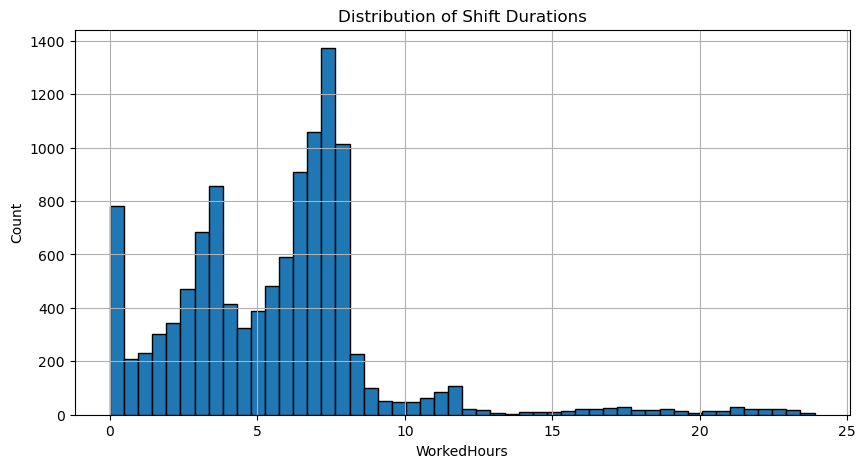

In [60]:
plt.figure(figsize=(10, 5))
daily_shifts['WorkedHours'].hist(bins=50, edgecolor='black')
plt.title('Distribution of Shift Durations')
plt.xlabel('WorkedHours')
plt.ylabel('Count')
plt.show()

In [74]:
min_hours = 2.0
shifts_cleaned = daily_shifts[daily_shifts['WorkedHours'] >= min_hours].copy()

print(f"Original Days: {len(daily_shifts)}")
print(f"Cleaned Days:  {len(shifts_cleaned)}")
print(f"Dropped {len(daily_shifts) - len(shifts_cleaned)} short shifts.")

Original Days: 11578
Cleaned Days:  10002
Dropped 1576 short shifts.


In [76]:
shifts_cleaned.describe()

,ResourceId,WorkedHours,WeekdayId,StartAsFloat,EndAsFloat
count,10002.000000,10002.000000,10002.000000,10002.000000,10002.000000
mean,59.843731,6.442457,2.157768,8.945588,15.388045
std,39.906769,3.283124,1.575518,2.913570,2.910105
min,1.000000,2.001431,0.000000,0.009167,6.621111
25%,27.000000,4.008635,1.000000,7.235069,13.757569
50%,53.000000,6.492297,2.000000,8.167361,14.936250
75%,98.000000,7.534203,3.000000,10.034653,16.967014
max,144.000000,23.887987,6.000000,18.460278,23.996944


### Derive weekly schedule by taking the median for each week day

In [78]:
weekly_schedule = shifts_cleaned.groupby(['ResourceId', 'Resource', 'WeekdayId']).agg(
    MedianStart=('StartAsFloat', 'median'),
    MedianEnd=('EndAsFloat', 'median'),
    ShiftCount=('Date', 'count')
).reset_index()

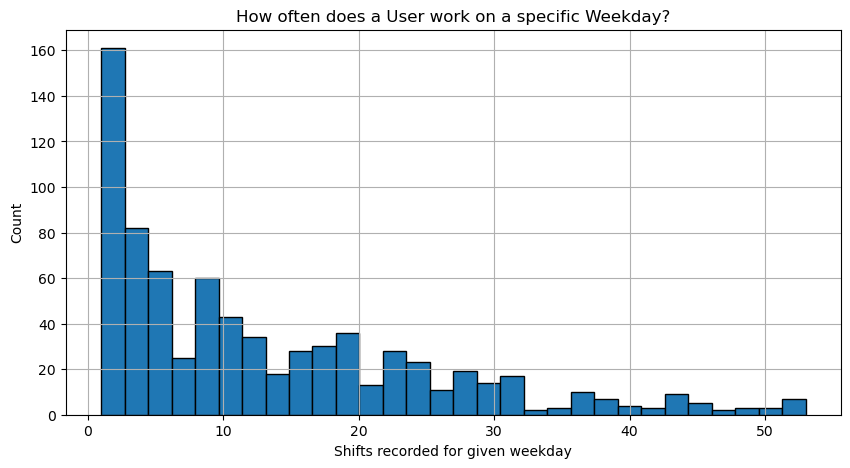

In [ ]:
plt.figure(figsize=(10, 5))
weekly_schedule['ShiftCount'].hist(bins=30, edgecolor='black')
plt.title('How often does a User work on a specific Weekday?')
plt.xlabel('Shift count for given weekday')
plt.ylabel('Count')
plt.show()

- most people don't work consistent hours

Convert back to Time object and export as csv

In [91]:
def float_to_time(x):
    hours = int(x)
    minutes = int((x - hours) * 60)
    return pd.to_datetime(f"{hours}:{minutes}", format="%H:%M").time()

weekly_schedule['StartTime'] = weekly_schedule['MedianStart'].apply(float_to_time)
weekly_schedule['EndTime'] = weekly_schedule['MedianEnd'].apply(float_to_time)

In [92]:
res_availvabilities = weekly_schedule[['Resource', 'WeekdayId', 'StartTime', 'EndTime']].copy()
res_availvabilities.rename(columns={'WeekdayId': 'DayId'}, inplace=True)
res_availvabilities.to_csv('weekly_schedule_median.csv', index=False)

## Deeper Analysis of resource availabilities for fixed intervals

#### WorkedHours

In [102]:
# Group daily durations by weekday
weekday_stats = daily_shifts.groupby(['Resource', 'ResourceId', 'WeekdayName', 'WeekdayId'])['WorkedHours'].agg(
    AverageHours='mean',
    MedianHours='median',
    StdDev='std',
    ShiftCount='count'
).reset_index()
weekday_stats['std/mean'] = weekday_stats['StdDev'] / weekday_stats['AverageHours']
weekday_stats = weekday_stats.sort_values(by=['ResourceId', 'WeekdayId'])

Global overview

In [116]:
global_weekday_stats = weekday_stats.groupby(['WeekdayId', 'WeekdayName'])['AverageHours'].agg(
    GlobalAverage='mean',
    GlobalMedian='median',
    GlobalStd='std',
    UserCount='count'
).reset_index()

global_weekday_stats = global_weekday_stats.sort_values('WeekdayId')
global_weekday_stats

,WeekdayId,WeekdayName,GlobalAverage,GlobalMedian,GlobalStd,UserCount
0,0,Monday,5.012140,5.237444,2.027863,139
1,1,Tuesday,5.096329,5.263664,2.120597,135
2,2,Wednesday,4.865275,5.022479,2.278437,141
3,3,Thursday,4.825884,4.823128,2.190126,137
4,4,Friday,4.551105,4.603604,2.043248,137
5,5,Saturday,4.755811,5.074261,2.005010,91
6,6,Sunday,4.073455,4.223083,3.223354,25


In [109]:
def get_metric_overview(metric):
    pivot_overview = weekday_stats.pivot(index='ResourceId', columns='WeekdayName', values=metric).fillna(0)
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    pivot_overview = pivot_overview.reindex(columns=days_order).sort_index()
    return pivot_overview.style.background_gradient(cmap='YlGnBu', axis=None).format("{:.1f}")

def color_thresholds(val):
    if val < 0.3:
        color ='#90EE90'
    elif val < 0.5:
        color = '#FFFFE0'
    else:
        color = '#FF7F7F'
    return f'background-color: {color}'

Average

In [105]:
avg_hours_overview = get_metric_overview('AverageHours')
avg_hours_overview.to_html("avg_hours.html")
print("Created 'avg_hours.html'")

Created 'avg_hours.html'


- User_1 consistent high activity => most likely system
- work hours around 4-6 hours
- some work consistently on Saturdays

Median

In [106]:
median_hours_overview = get_metric_overview('MedianHours')
median_hours_overview.to_html("median_hours.html")
print("Created 'median_hours.html'")

Created 'median_hours.html'


Relative Standard Deviation

In [110]:
std_hours_overview = get_metric_overview('StdDev')
std_hours_overview.to_html("std_hours.html")
print("Created 'std_hours.html'")

Created 'std_hours.html'


In [113]:
# Get better overview over relative standard deviation
pivot_relstd = weekday_stats.pivot(index='ResourceId', columns='WeekdayName', values='std/mean').fillna(0)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_relstd = pivot_relstd.reindex(columns=days_order).sort_index()
relstd_overview = pivot_relstd.style.map(color_thresholds).format("{:.1f}")
relstd_overview.to_html("relative_standard_deviation.html")
print("Created 'relative_standard_deviation.html'")

Created 'relative_standard_deviation.html'


#### Inspect resource shifts for single users

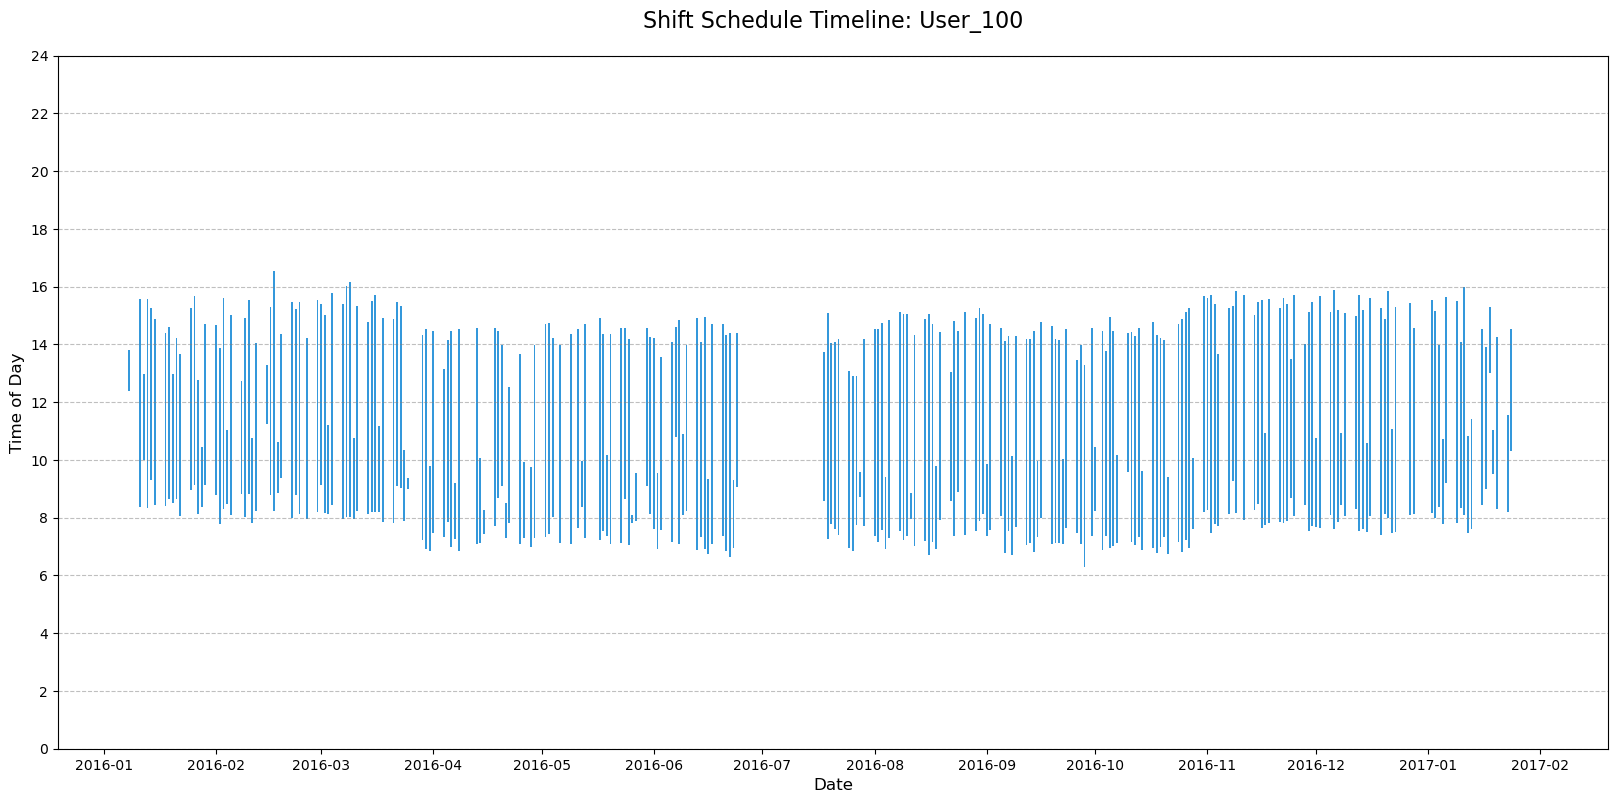

In [122]:
res_id = 'User_100'
tmp = daily_shifts[daily_shifts['Resource'] == res_id].copy()

fig, ax = plt.subplots(figsize=(20, 9))
ax.bar(
    mdates.date2num(tmp['Date']),
    tmp['WorkedHours'],
    bottom=tmp['StartTime'].apply(lambda x: x.hour + x.minute / 60),
    width=0.5,
    color='#3498db',
    edgecolor='none',
    align='center'
)
locator = mdates.MonthLocator(interval=1)
ax.xaxis.set_major_locator(locator)

formatter = mdates.DateFormatter('%Y-%m')
ax.xaxis.set_major_formatter(formatter)

ax.set_ylim(0, 24)
ax.set_yticks(range(0, 25, 2))
ax.set_ylabel("Time of Day", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5, color='gray')

ax.set_title(f"Shift Schedule Timeline: {res_id}", fontsize=16, pad=20)
ax.set_xlabel("Date", fontsize=12)

plt.show()

## Advanced Approach

#### Implement holidays

Find lower volume days based on daily shifts

In [180]:
daily_volume = daily_shifts.groupby(['Date', 'WeekdayId'])['WorkedHours'].sum().reset_index()

weekdays_only = daily_volume[daily_volume['WeekdayId'] < 5]
baseline_volume = weekdays_only['WorkedHours'].median()
print(f"Standard Daily Volume: {baseline_volume:.1f} hours")

threshold = 0.3
is_holiday = ((daily_volume['WeekdayId'] < 5) & 
        (daily_volume['WorkedHours'] < (baseline_volume * threshold)))
    
holidays = daily_volume[is_holiday].copy()
holidays['Ratio'] = holidays['WorkedHours'] / baseline_volume
holidays = holidays.sort_values('Date')
print(f"\nDetected {len(holidays)} Holidays:")
holidays

Standard Daily Volume: 224.6 hours

Detected 16 Holidays:


,Date,WeekdayId,WorkedHours,Ratio
0,2016-01-01,4,12.127297,0.054004
117,2016-04-27,2,42.222226,0.188021
125,2016-05-05,3,53.229695,0.237038
136,2016-05-16,0,56.043163,0.249567
360,2016-12-26,0,49.110984,0.218697
382,2017-01-17,1,63.046886,0.280756
384,2017-01-19,3,52.675935,0.234573
385,2017-01-20,4,62.544444,0.278518
388,2017-01-23,0,64.884578,0.288939
389,2017-01-24,1,38.352314,0.170788


from https://www.government.nl/topics/working-hours/question-and-answer/public-holidays-in-the-netherlands:
- New Year's: 01 January
- King's Day: 27 April
- Liberation Day: 5 May
- Ascension Day: different every year
- Christmas Day: 25 December
- Boxing Day: 26 December

In [181]:
holidays['Date'] = pd.to_datetime(holidays['Date'])
holidays_filtered = holidays[holidays['Date'].dt.year < 2017].copy()
holidays_filtered

,Date,WeekdayId,WorkedHours,Ratio
0,2016-01-01,4,12.127297,0.054004
117,2016-04-27,2,42.222226,0.188021
125,2016-05-05,3,53.229695,0.237038
136,2016-05-16,0,56.043163,0.249567
360,2016-12-26,0,49.110984,0.218697


In [186]:
daily_shifts['Date'] = pd.to_datetime(daily_shifts['Date'])
active_on_holiday = daily_shifts[
        (daily_shifts['Date'].isin(holidays_filtered['Date'].tolist())) & 
        (daily_shifts['WorkedHours'] > 0.01)
    ]
    
print("Users working on holidays:")
if active_on_holiday.empty:
    print("No one!")
else:
    workers_per_day = active_on_holiday.groupby('Date')['Resource'].unique()
    for date_val, workers in workers_per_day.items():
        worker_list = ", ".join(workers)
        print(f"   - {date_val}: {len(workers)} active ({worker_list})")

Users working on holidays:
   - 2016-01-01 00:00:00: 1 active (User_1)
   - 2016-04-27 00:00:00: 9 active (User_1, User_3, User_18, User_35, User_36, User_42, User_44, User_75, User_117)
   - 2016-05-05 00:00:00: 11 active (User_1, User_3, User_12, User_13, User_14, User_26, User_31, User_38, User_43, User_49, User_116)
   - 2016-05-16 00:00:00: 12 active (User_1, User_4, User_13, User_15, User_16, User_24, User_28, User_36, User_42, User_49, User_60, User_125)
   - 2016-12-26 00:00:00: 8 active (User_1, User_39, User_42, User_51, User_52, User_61, User_66, User_113)


In [118]:
# TODO implement breaks

In [117]:
# TODO new employees